# Pipeline klasyfikacji obrazów

Zbiór to zdjęcia śmieci z przypisanymi etykietami:
- cardboard
- glass
- metal
- paper
- plastic
- trash

## Preprocessing
Za nim co kolwiek zrobimy z danymi, powinniśmy na nie spojrzeć.

In [60]:
import pandas as pd
import sklearn
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
import matplotlib.pyplot as plt

In [61]:
raw_df = pd.read_csv('./train/_classes.csv')
raw_df.head()

,filename,cardboard,glass,metal,paper,plastic,trash
0,paper59_jpg.rf.wzR5NbRz2yDZECnFaw2m.jpg,0,0,0,1,0,0
1,plastic34_jpg.rf.wzyVtvyXtoYA45vl2U7m.jpg,0,0,0,0,1,0
2,glass131_jpg.rf.xKSWDJgXD3JxEOJrObp4.jpg,0,1,0,0,0,0
3,metal155_jpg.rf.xZPyMvYIV6SuhJdqYibK.jpg,0,0,1,0,0,0
4,metal53_jpg.rf.xvclQIoWptlLu6TuixHa.jpg,0,0,1,0,0,0


2524
filename     0
cardboard    0
glass        0
metal        0
paper        0
plastic      0
trash        0
dtype: int64


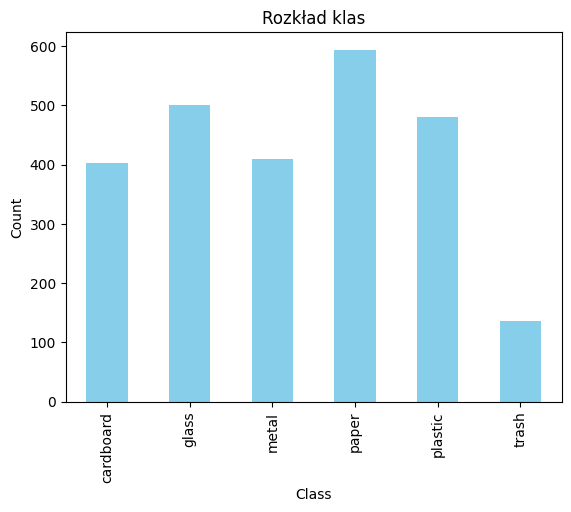

In [62]:
class_counts = raw_df.drop('filename', axis=1).sum()
print(class_counts.sum())
print(raw_df.isnull().sum()) 
class_counts.plot(kind='bar', color='skyblue', )
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Rozkład klas')
plt.show()

Nie ma pustych wartości, liczba klas jest równa liczbie zdjęć, więc nie ma sytuacji gdzie zdjęcie nie ma przypisanej klasy lub jest przypisane do kilku klas


In [63]:
import tensorflow as tf

class_names = raw_df.columns[1:]

file_names = raw_df['filename'].values
labels = raw_df[class_names].values

In [64]:
dataset = tf.data.Dataset.from_tensor_slices((file_names, labels))

def load_image(file_name, label):
    image = tf.io.read_file('./train/' + file_name) # tutaj jest nasze wczytywanie obrazu z pliku
    image = tf.image.decode_jpeg(image, channels=3) # tutaj jest nasze dekodowanie obrazu JPEG do formatu RGB
    image = tf.image.resize(image, [224, 224]) # tutaj jest nasze skalowanie do rozmiaru 224x224
    image = image / 255.0 # tutaj jest nasze unormowanie do zakresu [0, 1]
    return image, label

dataset = dataset.map(load_image)

train_dataset, other_dataset = tf.keras.utils.split_dataset(dataset, 0.7, seed=42)
val_dataset, test_dataset = tf.keras.utils.split_dataset(other_dataset, 0.5, seed=42)

train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

### To chyba tyle z przygotowań zbioru
- Dane są unormowane
- Etykiety są już OH-encoded

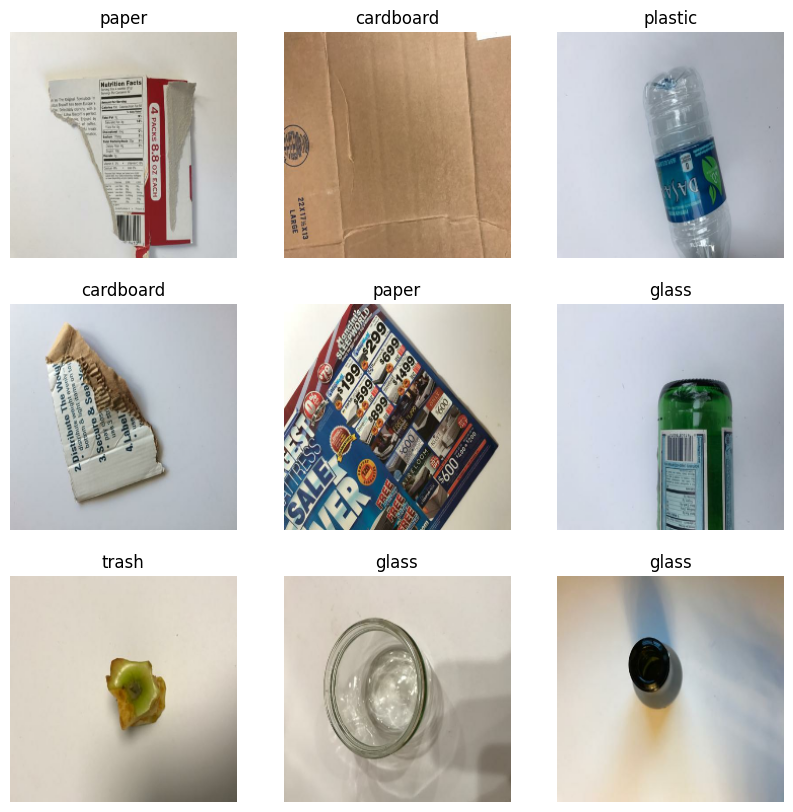

In [65]:
def show(dataset):
    for images, labels in dataset.take(1):
        plt.figure(figsize=(10, 10))
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy())
            class_list = [class_names[j] for j in range(len(class_names)) if labels[i][j] == 1]
            plt.title(', '.join(class_list))
            plt.axis("off")
    plt.show()

show(train_dataset)

Teraz jest ten śmieszny moment w którym trzeba stworzyć model, będę tutaj stosował po prostu wartości domyślne a jakieś poprawki wprowadzał później.

In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, add, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(Flatten(input_shape=(224, 224, 3)))
model.add(Dense(128, activation='relu'))
model.add(Dense(6, activation = 'softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

EarlyStop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=[EarlyStop])

c:\Users\lukas\ML\projekt_smieci\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 240ms/step - accuracy: 0.2275 - loss: 44.4148 - val_accuracy: 0.2989 - val_loss: 4.8107
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 241ms/step - accuracy: 0.2954 - loss: 5.4572 - val_accuracy: 0.2831 - val_loss: 3.7466
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 266ms/step - accuracy: 0.2716 - loss: 6.2891 - val_accuracy: 0.2222 - val_loss: 11.0869
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 241ms/step - accuracy: 0.2699 - loss: 5.5703 - val_accuracy: 0.2116 - val_loss: 7.0211
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 310ms/step - accuracy: 0.3277 - loss: 3.3308 - val_accuracy: 0.2910 - val_loss: 2.9551
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 236ms/step - accuracy: 0.2903 - loss: 3.3933 - val_accuracy: 0.2143 - val_loss: 3.3782
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 230ms/step - accuracy: 0.3667 - loss: 2.5426 - val_accuracy: 0.3730 - val_loss: 2.0943
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 14s 254ms/step - accuracy: 0.3254 - loss: 3.1944 - val_ac

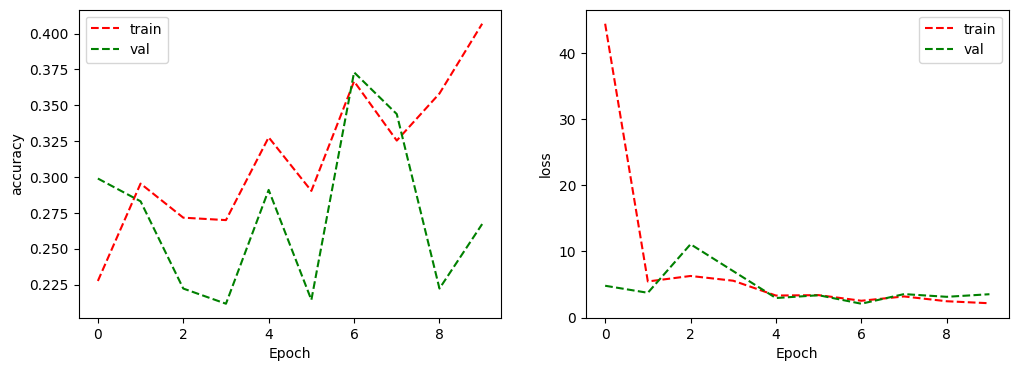

In [67]:
def draw_curves(history):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], "r--", label='train')
    plt.plot(history.history['val_accuracy'], "g--", label='val')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], "r--", label='train')
    plt.plot(history.history['val_loss'], "g--", label='val')
    plt.ylabel('loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.show()

draw_curves(history)